# Risk contribution

This example focuses on *where* risk lands rather than only on how much risk a portfolio
takes. It walks through two related workflows:

  - asset risk contribution under the variance measure, using the `rc` field to constrain
    per-asset contributions while comparing multiple objective functions;
  - factor risk contribution optimisation, where we constrain the contribution of specific
    factors and solve across multiple objectives.

> **When to reach for this**
>
> Reach for risk-contribution workflows when the allocation itself is not the point.
> They are useful when you want to see concentration in the realised risk profile, impose
> contribution limits directly in risk space, and compare how objective functions reshape
> the final risk profile under the same `rc` constraints.

In [1]:
using PortfolioOptimisers, PrettyTables

# Format for pretty tables.
resfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v * 100, digits = 3)) %" : v
    end
end;

## 1. ReturnsResult data

We use one year of S&P 500 prices and the matching factor returns slice used in the test
suite. The factor block is required for the factor-risk-contribution section.

In [2]:
using CSV, TimeSeries, DataFrames, Clarabel

X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
F = TimeArray(CSV.File(joinpath(@__DIR__, "..", "Factors.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X, F)

ReturnsResult
    nx ┼ 20-element Vector{String}
     X ┼ 252×20 Matrix{Float64}
    nf ┼ Vector{String}: ["MTUM", "QUAL", "SIZE", "USMV", "VLUE"]
     F ┼ 252×5 Matrix{Float64}
    nb ┼ nothing
     B ┼ nothing
    ts ┼ 252-element Vector{Date}
    iv ┼ nothing
  ivpa ┴ nothing


## 2. Shared optimiser setup

We pass a vector of solver configurations so the examples can fall back cleanly if the
first Clarabel configuration stalls on this data slice.

In [3]:
slv = [Solver(; name = :clarabel1, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false),
              check_sol = (; allow_local = true, allow_almost = true)),
       Solver(; name = :clarabel2, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false, "max_step_fraction" => 0.95),
              check_sol = (; allow_local = true, allow_almost = true)),
       Solver(; name = :clarabel3, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false, "max_step_fraction" => 0.9),
              check_sol = (; allow_local = true, allow_almost = true))]

pr = prior(EmpiricalPrior(), rd)
opt = JuMPOptimiser(; pe = pr, slv = slv)
sets_asset = AssetSets(; dict = Dict("nx" => rd.nx))
opt_asset = JuMPOptimiser(; pe = pr, slv = slv, sets = sets_asset)

JuMPOptimiser
       pe ┼ LowOrderPrior
          │         X ┼ 252×20 Matrix{Float64}
          │        mu ┼ 20-element Vector{Float64}
          │     sigma ┼ 20×20 Matrix{Float64}
          │      chol ┼ nothing
          │         w ┼ nothing
          │       ens ┼ nothing
          │       kld ┼ nothing
          │        ow ┼ nothing
          │        rr ┼ nothing
          │      f_mu ┼ nothing
          │   f_sigma ┼ nothing
          │       f_w ┴ nothing
      slv ┼ 3-element Vector{Solver}
          │ Solver ⋯
          │ Solver ⋯
          │ Solver ⋯
       wb ┼ WeightBounds
          │   lb ┼ Float64: 0.0
          │   ub ┴ Float64: 1.0
      bgt ┼ Float64: 1.0
     sbgt ┼ nothing
     gbgt ┼ nothing
     xbgt ┼ Bool: false
       lt ┼ nothing
       st ┼ nothing
     lcse ┼ nothing
      cte ┼ nothing
   gcarde ┼ nothing
  sgcarde ┼ nothing
     smtx ┼ nothing
    sgmtx ┼ nothing
      slt ┼ nothing
      sst ┼ nothing
     sglt ┼ nothing
     sgst ┼ nothing
       tn 

## 3. Asset risk contribution with `rc` constraints

`risk_contribution` decomposes the total risk of a portfolio into per-asset
contributions. Instead of using risk budgeting, we constrain contributions directly via
`Variance` using its `rc` field.

The same risk constraints are then solved under three different objectives to show how
objective choice changes weights while still respecting the contribution limits.

In [4]:
lcs_asset = LinearConstraintEstimator(; val = ["$a <= 0.2" for a in rd.nx])
r_asset = Variance(; rc = lcs_asset)
rf_asset = factory(r_asset, pr)

obj_specs = [(:min_risk, MinimumRisk()), (:max_utility, MaximumUtility()),
             (:max_ratio, MaximumRatio())]

asset_df = DataFrame(; assets = rd.nx)
asset_res = Dict{Symbol, Any}()

for (name, obj) in obj_specs
    res = optimise(MeanRisk(; r = r_asset, obj = obj, opt = opt_asset))
    asset_res[name] = res
    rcs = risk_contribution(rf_asset, res.w, pr.X)
    rcs ./= sum(rcs)
    asset_df[!, Symbol("$(name)_weight")] = res.w
    asset_df[!, Symbol("$(name)_risk")] = rcs
end

pretty_table(asset_df; formatters = [resfmt])

┌────────┬─────────────────┬───────────────┬────────────────────┬───────────────
│ assets │ min_risk_weight │ min_risk_risk │ max_utility_weight │ max_utility_ ⋯
│ String │         Float64 │       Float64 │            Float64 │          Flo ⋯
├────────┼─────────────────┼───────────────┼────────────────────┼───────────────
│   AAPL │           0.0 % │         0.0 % │              0.0 % │            0 ⋯
│    AMD │           0.0 % │         0.0 % │              0.0 % │            0 ⋯
│    BAC │           0.0 % │         0.0 % │              0.0 % │            0 ⋯
│    BBY │           0.0 % │         0.0 % │              0.0 % │            0 ⋯
│    CVX │         9.212 % │       9.707 % │              0.0 % │            0 ⋯
│     GE │         0.407 % │       0.425 % │              0.0 % │            0 ⋯
│     HD │           0.0 % │         0.0 % │              0.0 % │            0 ⋯
│    JNJ │        21.939 % │        20.0 % │              0.0 % │            0 ⋯
│    JPM │         1.652 % │

Even when all solutions satisfy the same per-asset contribution caps, objective functions
still produce different weights and risk-contribution shapes.

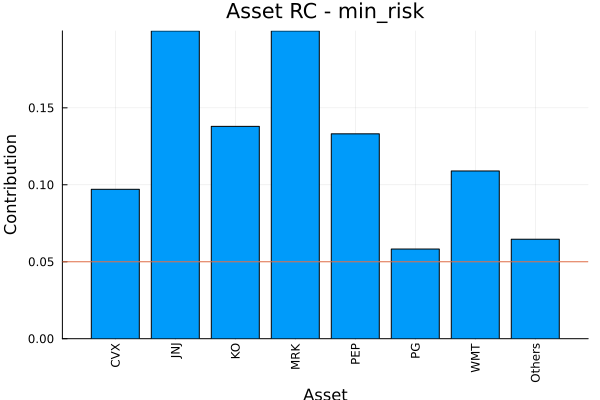

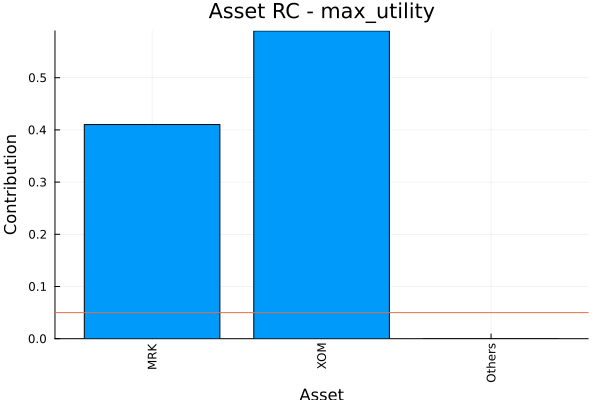

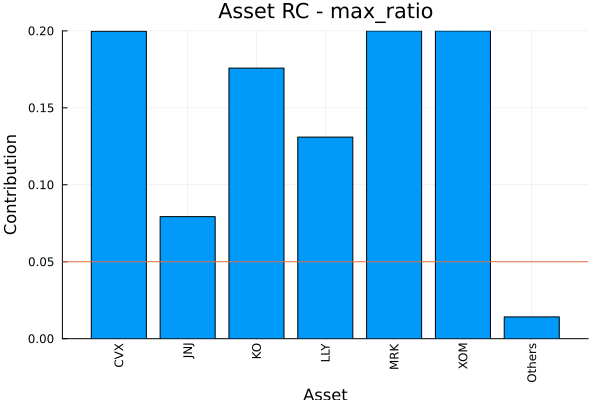

In [5]:
using StatsPlots, GraphRecipes

for (name, _) in obj_specs
    display(plot_risk_contribution(rf_asset, asset_res[name], rd;
                                   title = "Asset RC - $(name)"))
end

## 4. Factor risk contribution optimisation

`FactorRiskContribution` works one layer higher: instead of decomposing risk across
assets only, it uses factor regression to impose or inspect contribution targets on named
factors. The regression estimator needs the factor-return data at optimisation time, so we
pass `rd` directly to `optimise`.

The factor side mirrors the same idea: `rc` constraints are fixed, while objectives vary.

┌───────────┬───────────────┬──────────────────┬────────────────┐
│    factor │ min_risk_risk │ max_utility_risk │ max_ratio_risk │
│    String │       Float64 │          Float64 │        Float64 │
├───────────┼───────────────┼──────────────────┼────────────────┤
│      MTUM │       5.299 % │         10.532 % │          9.0 % │
│      QUAL │       9.545 % │        -13.214 % │       -6.459 % │
│      SIZE │     -60.711 % │        -42.157 % │      -48.675 % │
│      USMV │      90.242 % │          64.72 % │       73.014 % │
│      VLUE │      55.626 % │         80.119 % │        73.12 % │
│ Intercept │         0.0 % │            0.0 % │          0.0 % │
└───────────┴───────────────┴──────────────────┴────────────────┘


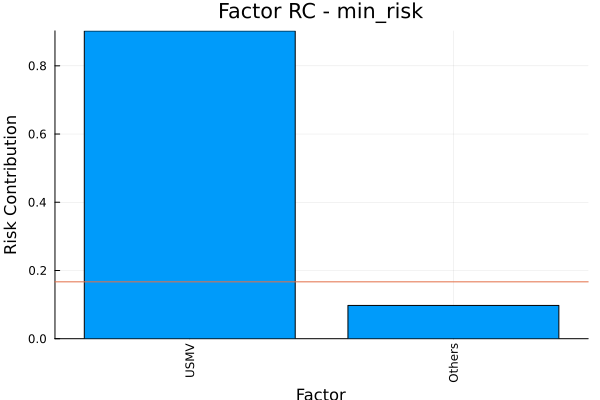

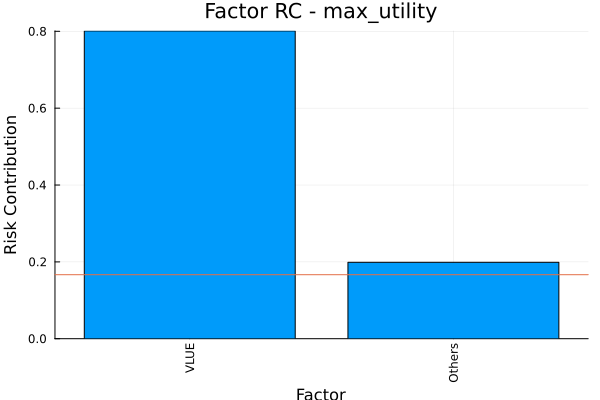

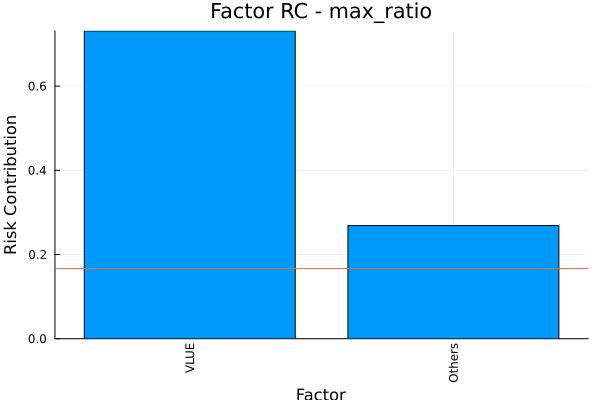

In [6]:
sets = AssetSets(; dict = Dict("nx" => rd.nf))
lcs = LinearConstraintEstimator(; val = ["VLUE <= 0.74", "QUAL >= -0.07", "MTUM==0.09"])
r_fac = Variance(; rc = lcs)

rf_fac = factory(r_fac, pr)
factor_df = DataFrame(; factor = [rd.nf; "Intercept"])
factor_res = Dict{Symbol, Any}()

for (name, obj) in obj_specs
    res = optimise(FactorRiskContribution(; r = r_fac, obj = obj, opt = opt, sets = sets),
                   rd)
    factor_res[name] = res
    frc_risk = factor_risk_contribution(rf_fac, res.w, pr.X; rd = rd)
    frc_risk ./= sum(frc_risk)
    factor_df[!, Symbol("$(name)_risk")] = frc_risk
end

pretty_table(factor_df; formatters = [resfmt])

for (name, _) in obj_specs
    display(plot_factor_risk_contribution(rf_fac, factor_res[name], rd;
                                          title = "Factor RC - $(name)"))
end

## Summary

Risk contribution workflows answer a different question from plain mean-risk optimisation:

  - `Variance` with `rc` constraints directly limits realised risk contribution,
    either by asset or by factor.
  - `MeanRisk` and `FactorRiskContribution` can be run with the same
    constraints and different objective functions to compare allocations and concentration.
  - `risk_contribution` and `factor_risk_contribution` verify whether the
    solved portfolio's realised profile matches your intended contribution policy.

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*